# 05. Timeline (Version 4)

How has station activity changed since 2023? This notebook loads every year of Rapid Rail data, builds **monthly** average daily entries for each station (for the map's time slider), and compares the **same season** in two years (for the "change since 2023" colouring).

| Section | What it does |
|---|---|
| 0 | Settings |
| 1 | Load each year (downloaded once, then cached) |
| 2 | Match line codes to the places on the map |
| 3 | Monthly average daily entries per station |
| 4 | Change between the same season in two years |
| 5 | Checks |
| 6 | Save the outputs |

**Network changes to keep in mind:** the Putrajaya Line's second phase (Kampung Batu to Putrajaya Sentral) opened on 16 March 2023, and the Shah Alam Line (LRT3) on 29 June 2026, with taps recorded from 1 August 2026. As in `01datapreparation.ipynb`, each line code is averaged only over the days it was in service, and stations without enough data in the earlier season are marked **new** instead of being given a growth figure.

Needs `data/processed/stations.geojson` from `01datapreparation.ipynb`.

## 0. Settings

In [1]:
from pathlib import Path
import re, json
from datetime import datetime
import requests
import pandas as pd
import geopandas as gpd

FIRST_YEAR = 2023                 # <- earliest year to load (the data starts in 2023)
REFRESH_CURRENT_YEAR = True       # <- True = re-download the current year's file, which grows every day

# Same-season comparison for the "change since" colouring
SEASON = ("06-01", "08-31")       # <- (start, end) as month-day; June to August, like the main map
COMPARE_FROM = 2023               # <- earlier year
COMPARE_TO = 2026                 # <- later year
MIN_SEASON_DAYS = 30              # <- a station needs at least this many days of data in BOTH seasons for a growth figure

MIN_MONTH_DAYS = 7                # <- months where a line code has fewer days of data are left blank on the slider

PROCESSED = Path("data/processed")
RAW = Path("data/raw")
RAW.mkdir(parents=True, exist_ok=True)
OD_URL = "https://storage.data.gov.my/transportation/rail/rapidrail_{year}_daily.parquet"
this_year = datetime.now().year
YEARS = list(range(FIRST_YEAR, this_year + 1))
print("Years to load:", YEARS)

Years to load: [2023, 2024, 2025, 2026]


## 1. Load each year

Only the **station entry totals** are kept (rows from a station to `A0: All Stations`, as in notebook 01), which cuts each year from millions of rows to about 60,000.

In [2]:
def get_year(year):
    path = RAW / f"rapidrail_{year}_daily.parquet"
    if not path.exists() or (REFRESH_CURRENT_YEAR and year == this_year):
        url = OD_URL.format(year=year)
        print(f"Downloading {url}")
        r = requests.get(url, timeout=600)
        r.raise_for_status()
        path.write_bytes(r.content)
    else:
        print(f"Using cached {path}")
    df = pd.read_parquet(path)
    df = df[~df["origin"].str.startswith("A0:") & df["destination"].str.startswith("A0:")]
    df = df[["origin", "date", "ridership"]].rename(columns={"origin": "od_station"})
    df["date"] = pd.to_datetime(df["date"])
    return df

entries = pd.concat([get_year(y) for y in YEARS], ignore_index=True)
entries = entries.groupby(["od_station", "date"], as_index=False)["ridership"].sum()
print(f"\n{len(entries):,} station-days from {entries['date'].min().date()} to {entries['date'].max().date()}")
print(entries.groupby(entries["date"].dt.year)["od_station"].nunique().rename("line codes with data").to_string())


219,456 station-days from 2023-01-01 to 2026-09-27
date
2023    166
2024    166
2025    146
2026    166


## 2. Match line codes to the places on the map

Each line code is matched to a place in `stations.geojson` by its **code** first (e.g. `KG18`), then by its **cleaned name**, using the same rules as notebook 01. Any code that matches neither is listed: it may be a station that was renamed or re-coded over the years.

In [3]:
def clean(s):
    s = str(s).lower()
    s = re.sub(r"^[a-z]{1,3}\d{1,3}\s*[:\-]\s*", "", s)
    s = s.split(" - ")[0]
    s = re.sub(r"\b(lrt|mrt|monorail|stesen|station)\b", "", s)
    return re.sub(r"[^a-z0-9]", "", s)

def norm_code(s):
    m = re.match(r"^\s*([A-Za-z]{1,3})0*(\d{1,3})\b", str(s))
    return (m.group(1) + m.group(2)).upper() if m else None

stations = gpd.read_file(PROCESSED / "stations.geojson")
code_to_key = {c.strip(): k for k, codes in zip(stations["key"], stations["codes"]) for c in str(codes).split(",")}
known_keys = set(stations["key"])

codes = pd.DataFrame({"od_station": entries["od_station"].unique()})
codes["by_code"] = codes["od_station"].map(norm_code).map(code_to_key)
codes["by_name"] = codes["od_station"].map(clean).where(lambda s: s.isin(known_keys))
codes["key"] = codes["by_code"].fillna(codes["by_name"])

unmatched = codes[codes["key"].isna()]
print(f"Matched {codes['key'].notna().sum()} of {len(codes)} line codes "
      f"({(codes['by_code'].notna()).sum()} by code, {(codes['by_code'].isna() & codes['by_name'].notna()).sum()} by name only)")
if len(unmatched):
    print("NOT MATCHED (left out; check for renamed or re-coded stations):")
    display(unmatched[["od_station"]])
entries = entries.merge(codes[["od_station", "key"]], on="od_station").dropna(subset=["key"])

Matched 166 of 166 line codes (166 by code, 0 by name only)


## 3. Monthly average daily entries

For each line code and month: total entries divided by the days in that month since the code's **first day with data**. A code with fewer than `MIN_MONTH_DAYS` days of data in a month is left blank for that month. A place's monthly figure is the sum of its line codes.

In [4]:
first_day = entries[entries["ridership"] > 0].groupby("od_station")["date"].min()
entries = entries[entries["date"] >= entries["od_station"].map(first_day)]    # drop days before a code opened

entries["month"] = entries["date"].dt.to_period("M")
by_code = entries.groupby(["od_station", "key", "month"]).agg(total=("ridership", "sum"), days=("date", "nunique")).reset_index()
by_code = by_code[by_code["days"] >= MIN_MONTH_DAYS]
by_code["avg"] = by_code["total"] / by_code["days"]

monthly = by_code.groupby(["key", "month"])["avg"].sum().round(0).reset_index(name="avg_daily_entries")
last_month = monthly["month"].max()
# Drop the latest month if it is still incomplete (fewer than 25 days so far)
days_in_last = entries.loc[entries["month"] == last_month, "date"].nunique()
if days_in_last < 25:
    monthly = monthly[monthly["month"] < last_month]
    print(f"Left out {last_month}: only {days_in_last} days so far")

months = sorted(monthly["month"].unique())
print(f"{len(months)} months: {months[0]} to {months[-1]}; {monthly['key'].nunique()} places")

network = monthly.groupby("month")["avg_daily_entries"].sum()
print("\nWhole network, average daily entries by month (every 3rd month):")
print(network.iloc[::3].map("{:,.0f}".format).to_string())

45 months: 2023-01 to 2026-09; 154 places

Whole network, average daily entries by month (every 3rd month):
month
2023-01    400,728
2023-04    397,590
2023-07    451,079
2023-10    489,665
2024-01    498,683
2024-04    497,048
2024-07    558,162
2024-10    573,192
2025-01    554,784
2025-04    565,469
2025-07    614,892
2025-10    595,353
2026-01    600,869
2026-04    614,604
2026-07    628,523
Freq: M


## 4. Change between the same season in two years

Comparing the **same months** (June to August by default) avoids mixing growth with seasonal effects such as school holidays and festivals. Only **line codes with at least `MIN_SEASON_DAYS` days of data in both seasons** are compared, so a platform added later (such as LRT3 at Bandar Utama) does not count as growth; such cases get a note. A place with no line code in the earlier season is marked **new**.

In [5]:
def season_by_code(year):
    lo, hi = pd.Timestamp(f"{year}-{SEASON[0]}"), pd.Timestamp(f"{year}-{SEASON[1]}")
    e = entries[(entries["date"] >= lo) & (entries["date"] <= hi)]
    c = e.groupby(["od_station", "key"]).agg(total=("ridership", "sum"), days=("date", "nunique"))
    c["avg"] = c["total"] / c["days"]
    return c[c["days"] >= MIN_SEASON_DAYS]

a, b = season_by_code(COMPARE_FROM), season_by_code(COMPARE_TO)
both = a.index.intersection(b.index)              # line codes with enough data in both seasons

growth = pd.DataFrame(index=stations["key"])
growth[f"avg_{COMPARE_FROM}"] = a.loc[both, "avg"].groupby(level="key").sum().round(0)
growth[f"avg_{COMPARE_TO}"] = b.loc[both, "avg"].groupby(level="key").sum().round(0)
growth["change_pct"] = ((growth[f"avg_{COMPARE_TO}"] / growth[f"avg_{COMPARE_FROM}"] - 1) * 100).round(1)
growth["status"] = "compared"
growth.loc[growth["change_pct"].isna(), "status"] = f"new since {COMPARE_FROM}"

# Line codes in the later season that are not compared (e.g. a new LRT3 platform at an existing place)
extra = b.index.difference(both)
extra_note = pd.Series([c for c, k in extra], index=[k for c, k in extra]).groupby(level=0).apply(
    lambda s: "not compared (opened later): " + ", ".join(x.split(":")[0] for x in s))
growth["note"] = growth.index.map(extra_note).fillna("")
growth.loc[growth["status"] != "compared", "note"] = ""
growth = growth.join(stations.set_index("key")[["name", "codes"]])
ok = growth["status"] == "compared"

net_a, net_b = growth.loc[ok, f"avg_{COMPARE_FROM}"].sum(), growth.loc[ok, f"avg_{COMPARE_TO}"].sum()
print(f"Season {SEASON[0]} to {SEASON[1]}, {COMPARE_FROM} vs {COMPARE_TO}")
print(f"Stations compared: {ok.sum()} | new since {COMPARE_FROM}: {(~ok).sum()}")
print(f"Compared stations together: {net_a:,.0f} -> {net_b:,.0f} entries a day ({(net_b / net_a - 1) * 100:+.1f}%)")
print(f"Median station change: {growth['change_pct'].median():+.1f}%")

Season 06-01 to 08-31, 2023 vs 2026
Stations compared: 135 | new since 2023: 19
Compared stations together: 459,458 -> 603,989 entries a day (+31.5%)
Median station change: +29.0%


## 5. Checks

Biggest growth:


,name,codes,avg_2023,avg_2026,change_pct
key,,,,,
pusatbandardamansara,Pusat Bandar Damansara,KG13,1456.0,4994.0,243.0
sultanismail,Sultan Ismail,AG5,531.0,1746.0,228.8
kwasadamansara,Kwasa Damansara,KG4,578.0,1760.0,204.5
tunrazakexchange,Tun Razak Exchange,KG20,5116.0,15566.0,204.3
putrapermai,Putra Permai,PYL37,351.0,1017.0,189.7
kuchai,Kuchai,PYL27,1155.0,2891.0,150.3
conlay,Conlay,PYL22,819.0,2033.0,148.2
cgcglenmarie,Cgc Glenmarie,KJ27,3341.0,8111.0,142.8


Biggest decline:


,name,codes,avg_2023,avg_2026,change_pct
key,,,,,
damai,Damai,KJ8,1966.0,1813.0,-7.8
chowkit,Chow Kit,MR10,3659.0,3586.0,-2.0
masjidjamek,Masjid Jamek,"AG7, KJ13",15672.0,15786.0,0.7
subangjaya,Subang Jaya,KJ28,4772.0,4823.0,1.1
klsentral,KL Sentral,"KJ15, MR1",25539.0,26398.0,3.4
kelanajaya,Kelana Jaya,KJ24,2383.0,2490.0,4.5
setiawangsa,Setiawangsa,KJ5,3704.0,3892.0,5.1
klcc,KLCC,KJ10,20427.0,21710.0,6.3


New since 2023:


,name,codes
key,,
bandarbaruklang,Bandar Baru Klang,SA17
bandarbukittinggi,Bandar Bukit Tinggi,SA24
bandarutama11,Bandar Utama 11,SA3
damansaraidaman,Damansara Idaman,SA5
datomenteri,Dato' Menteri - SA Sentral,SA12
glenmarie2,Glenmarie 2,SA7
jalanmeru,Jalan Meru,SA19
jambatankota,Jambatan Kota,SA20
johansetia,Johan Setia,SA26


Places where part of the station opened later (only the older line codes are compared):


,name,codes,change_pct,note
key,,,,
bandarutama,Bandar Utama,"KG9, SA1",68.6,not compared (opened later): SA01


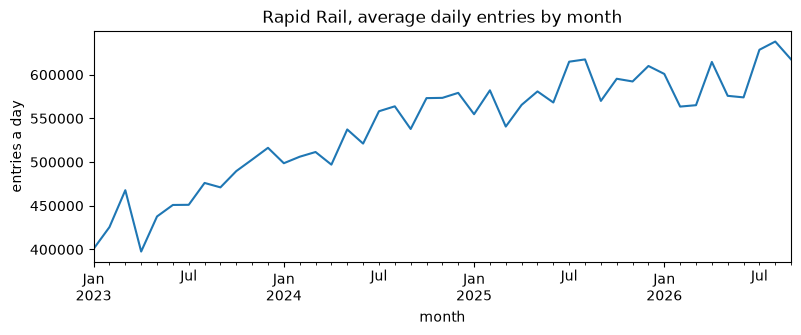

In [6]:
cols = ["name", "codes", f"avg_{COMPARE_FROM}", f"avg_{COMPARE_TO}", "change_pct"]
print("Biggest growth:")
display(growth.nlargest(8, "change_pct")[cols])
print("Biggest decline:")
display(growth.nsmallest(8, "change_pct")[cols])
print(f"New since {COMPARE_FROM}:")
display(growth[growth["status"] != "compared"][["name", "codes"]])
print("Places where part of the station opened later (only the older line codes are compared):")
display(growth[growth["note"] != ""][["name", "codes", "change_pct", "note"]])

# Optional chart of the whole network over time (needs matplotlib)
try:
    import matplotlib.pyplot as plt
    ax = network.to_timestamp().plot(figsize=(9, 3), title="Rapid Rail, average daily entries by month")
    ax.set_ylabel("entries a day"); plt.show()
except ImportError:
    print("(Install matplotlib to see a chart of the network over time.)")

## 6. Save the outputs

In [7]:
out_monthly = monthly.copy()
out_monthly["month"] = out_monthly["month"].astype(str)
out_monthly.to_csv(PROCESSED / "station_monthly.csv", index=False)
growth.reset_index()[["key", f"avg_{COMPARE_FROM}", f"avg_{COMPARE_TO}", "change_pct", "status", "note"]].to_csv(
    PROCESSED / "station_growth.csv", index=False)

meta = {"months": [str(m) for m in months], "season": list(SEASON), "compare_from": COMPARE_FROM,
        "compare_to": COMPARE_TO, "min_season_days": MIN_SEASON_DAYS,
        "network_change_pct": round(float((net_b / net_a - 1) * 100), 1),
        "prepared_on": datetime.now().strftime("%Y-%m-%d"),
        "notes": ["Monthly figures are average daily entries over the days each line code had data.",
                  "Putrajaya Line phase 2 opened 16 March 2023; Shah Alam Line (LRT3) opened 29 June 2026, taps from 1 August 2026."]}
(PROCESSED / "timeline_metadata.json").write_text(json.dumps(meta, indent=2))

for f in ["station_monthly.csv", "station_growth.csv", "timeline_metadata.json"]:
    print(f"{f:24} {(PROCESSED / f).stat().st_size / 1e3:8.0f} KB")

station_monthly.csv           167 KB
station_growth.csv              6 KB
timeline_metadata.json          1 KB


___
**END**